# Exploratory Data Analysis (EDA) по научным публикациям arXiv

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi

import plotly.express as px
import plotly.graph_objects as go

## Общая картина

## NLP статьи

In [ ]:
df_nlp = pd.read_csv('../../data/metadata/arxiv_NLP_1994_2026_metadata.csv', usecols=['arxiv_id', 'published'])

In [ ]:
df_arxiv_stats = pd.read_csv('../../data/raw/arxiv_monthly_submittions.csv', usecols=['month', 'submissions'])
df_arxiv_stats['month'] = pd.to_datetime(df_arxiv_stats['month'])

In [ ]:
fig = px.area(
    df_arxiv_stats, 
    x='month', 
    y='submissions',
    title="Рост количества публикаций на arXiv (1991–2026)"
)

fig.update_traces(
    line=dict(color='#525bcb', width=2) 
)

events = [
    {
        "date": "2017-06-12", 
        "label": 'Статья "Attention is all you need"', 
        "y_pos": 0.75
    },
    {
        "date": "2022-11-01", 
        "label": "ChatGPT Release", 
        "y_pos": 0.9
    }
]

for event in events:
    # Вертикальная линия (твой зеленый #009639)
    fig.add_vline(
        x=event["date"], 
        line_width=2, 
        line_dash="dash", 
        line_color="#009639", 
        opacity=0.8
    )
    
    # Текст (белый, жирный)
    fig.add_annotation(
        x=event["date"],
        y=event["y_pos"],
        yref="paper",
        text=f" {event['label']} ",
        showarrow=False,
        font=dict(color="white", size=12, weight="bold"),
        xanchor="right"
    )

fig.update_layout(
    font=dict(color='white'),
    xaxis_title="Год",
    yaxis_title="Количество статей в месяц",
    paper_bgcolor='rgba(0, 0, 0, 0)',
    plot_bgcolor='rgba(0, 0, 0, 0)',
    width=1000,
    height=600,
    margin=dict(t=60, b=50, l=50, r=50),
    hovermode="x unified" # Очень удобно для графиков с высокой плотностью
)

fig.update_xaxes(showgrid=True, gridcolor='rgba(255, 255, 255, 0.1)', zeroline=False)
fig.update_yaxes(showgrid=True, gridcolor='rgba(255, 255, 255, 0.1)', zeroline=False)

fig.show()
fig.write_image('../../data/fig/arxiv_growth.png', scale=2)

In [ ]:
df_nlp['published'] = pd.to_datetime(df_nlp['published'])
df_nlp_yearly = df_nlp.resample('YE', on='published').size().reset_index(name='submissions')
df_nlp_yearly = df_nlp_yearly.rename(columns={'published': 'year'})

# Игнорим 2026 год
df_nlp_yearly = df_nlp_yearly.iloc[:-1]

In [ ]:
# Создаем основной линейный график
fig = px.area(
    df_nlp_yearly, 
    x='year', 
    y='submissions',
    title="История NLP статей (1994–2025)",
    markers=True
)

fig.update_traces(
    line=dict(color='#525bcb', width=3),
    marker=dict(size=8)
)

events = [
    {
        "date": "2017-06-12", 
        "label": 'Статья "Attention is all you need"', 
        "y_pos": 0.75
    },
    {
        "date": "2022-11-01", 
        "label": "ChatGPT", 
        "y_pos": 0.85
    }
]

for event in events:
    fig.add_vline(
        x=event["date"], 
        line_width=2, 
        line_dash="dash", 
        line_color="#009639", 
        opacity=0.7
    )
    
    fig.add_annotation(
        x=event["date"],
        y=event["y_pos"],
        yref="paper",
        text=f" {event['label']} ",
        showarrow=False,
        font=dict(color="#ffffff", size=12, weight="bold"),
        xanchor="right"
    )

fig.update_layout(
    font=dict(color='white'),
    xaxis_title="Год",
    yaxis_title="Количество статей в год",
    paper_bgcolor='rgba(0, 0, 0, 0)',
    plot_bgcolor='rgba(0, 0, 0, 0)',
    width=1000,
    height=600,
    margin=dict(t=50, b=50, l=50, r=50)
)

fig.update_xaxes(showgrid=True, gridcolor='rgba(255, 255, 255, 0.1)', zeroline=False)
fig.update_yaxes(showgrid=True, gridcolor='rgba(255, 255, 255, 0.1)', zeroline=False)

fig.show()
fig.write_image('../../data/fig/nlp_growth.png', scale=2)

### Доля NLP статей

In [ ]:
df_nlp_yearly['year'] = pd.to_datetime(df_nlp_yearly['year'])

df_years_comparison = (
    df_nlp_yearly
    .assign(period=np.where(df_nlp_yearly['year'].dt.year < 2025, 'Before 2025', '2025'))
    .groupby('period')['submissions']
    .sum()
    .reset_index()
)

df_years_comparison

In [ ]:
labels = df_years_comparison['period']
values = df_years_comparison['submissions']

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.7,)])

fig.update_traces(
    hoverinfo='label+percent',
    textinfo='value',
    marker=dict(colors=['#eaaa00', '#009639']),
    textfont=dict(size=24, color='#ffffff'),
    pull=[0.1, 0]
)

fig.update_layout(
    paper_bgcolor='rgba(0, 0, 0, 0)',
    showlegend=False,
    margin=dict(t=20, b=100, l=20, r=20)
)

fig.show()
fig.write_image('../../data/fig/nlp_years_comparison.svg', width=512, height=512)

## Метрики

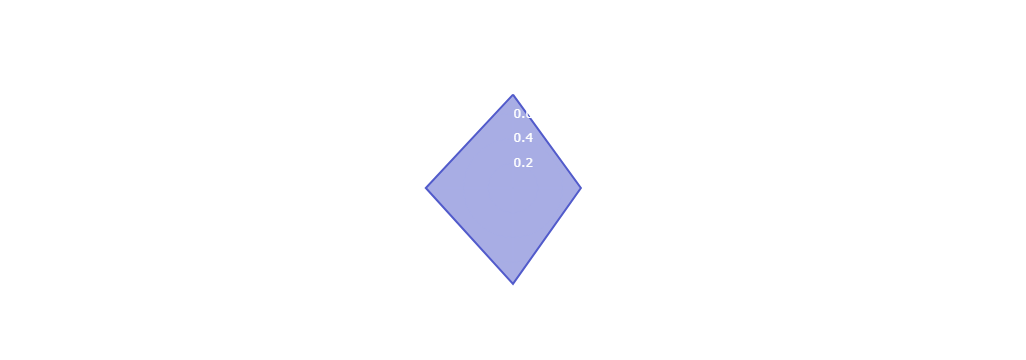

In [66]:
import plotly.express as px

metrics = {
    'Context Recall': 0.7525,
    'Context Precision': 0.5476,
    'Answer Relevancy': 0.7734, 
    'Faithfulness': 0.7034
}


# 3. Отрисовка без лишнего pandas
# Plotly Express отлично принимает словари напрямую
fig = px.line_polar(
    r=list(metrics.values()),
    theta=list(metrics.keys()),
    line_close=True,
    range_r=[0, 1], # Явно задаем масштаб для RAGAS
    title="RAG Evaluation Metrics"
)

fig.update_traces(fill='toself', line_color='#525bcb')

fig.update_layout(
    title={
        'text': "RAG Evaluation Metrics",
        'x': 0.5,
        'y': 0.95,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20, 'color': 'white'}
    },
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(color='white'),
    polar=dict(
        bgcolor='rgba(0,0,0,0)',
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickvals=[0.2, 0.4, 0.6, 0.8, 1.0],
            tickangle=90,
            angle=90,
            tickfont=dict(size=12, color="white"),
            gridcolor="rgba(255, 255, 255, 0.2)",
            showline=False,
        ),
        angularaxis=dict(
            rotation=90,
            direction="clockwise",
            tickfont=dict(size=14, color="white", family="Arial"),
            gridcolor="rgba(255, 255, 255, 0.2)"
        )
    ),
    margin=dict(l=72, r=72, t=64, b=48) 
)

fig.show()
fig.write_image('../../data/fig/radar_metrics.png', scale=2)